# Lecture 14.3 YOLO

**Тема:** семейство YOLO, почему one-stage detection изменил практическое computer vision, и как обучать и запускать современный YOLO-пайплайн  
**Аудитория:** студенты, которые уже видели общую идею детекции и хотят понять практический, deployment-oriented взгляд  
**Цель:** понять исходную интуицию YOLO, эволюцию до современных систем и рабочий процесс через пакет Ultralytics

Эта версия заметно расширяет теорию и связывает историческую идею с тем инструментарием, с которым студент действительно встретится в реальных проектах.


## План

1. Почему YOLO был важным историческим шагом  
2. Исходная grid-based идея  
3. Чем современные YOLO отличаются от YOLOv1  
4. Сигналы обучения: box loss, objectness, classes  
5. Реальное обучение и инференс через Ultralytics  
6. Области применения, компромиссы и упражнения


In [1]:
from __future__ import annotations

import math
import random
from pathlib import Path

import numpy as np

MPL_AVAILABLE = True
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
except Exception as exc:
    MPL_AVAILABLE = False
    print(f"matplotlib недоступен: {exc}")

PIL_AVAILABLE = True
try:
    from PIL import Image
except Exception as exc:
    PIL_AVAILABLE = False
    print(f"Pillow недоступен: {exc}")

TORCH_AVAILABLE = True
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
except Exception as exc:
    TORCH_AVAILABLE = False
    print(f"PyTorch недоступен: {exc}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

print(f"matplotlib available: {MPL_AVAILABLE}")
print(f"Pillow available: {PIL_AVAILABLE}")
print(f"PyTorch available: {TORCH_AVAILABLE}")


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


matplotlib available: True
Pillow available: True
PyTorch available: True


## 1. Почему YOLO стал важной вехой

До YOLO многие сильные детекторы строились как более медленный конвейер:

- сначала предложить регионы  
- потом классифицировать их  
- потом уточнить боксы

YOLO изменил саму формулировку задачи, представив детекцию как **единую end-to-end задачу предсказания**. Вместо независимой классификации множества crop-ов сеть смотрела на все изображение сразу и предсказывала все объекты за один проход.

Это было важно по двум причинам:

- стало быстрее  
- изменился сам способ думать о детекции

Историческая роль YOLO не только в том, что он был быстрым. Он сделал one-stage detection естественной моделью для real-time perception.


![YOLO grid intuition](images/yolo_grid.svg)

На схеме хорошо видна исходная интуиция: пространство изображения организуется в набор позиций предсказания, каждая из которых отвечает за структурированный прогноз. Современные YOLO намного сложнее YOLOv1, но идея «смотреть на картинку целиком и предсказывать все сразу» остается ядром семейства.


## 2. Исходная идея YOLO простыми словами

YOLOv1 делил изображение на сетку. Каждая ячейка сетки предсказывала:

- находится ли центр объекта внутри этой ячейки  
- один или несколько bounding boxes  
- вероятности классов

Почему это оказалось мощно?

Потому что модель рассуждала о сцене целиком. Область не классифицировалась изолированно. Сеть одновременно училась и глобальному контексту, и локализации.

**YOLO превращает детекцию в одну связанную задачу предсказания, а не в pipeline proposal-ов.**


## 3. YOLO тогда и сейчас

Важно не путать “исходную статью YOLO” и “все, что сегодня называют YOLO”.

### YOLOv1

- исторически очень важная работа  
- grid-based формулировка  
- архитектурно значительно проще современных версий  
- слабее работал с маленькими объектами

### Более поздние поколения

Современные YOLO улучшили базовую идею за счет:

- более сильных backbone  
- feature pyramid и multi-scale head  
- лучшего присвоения меток
- более мощной аугментации  
- более качественных loss-функций и тренировочных эвристик  

Поэтому когда сегодня инженер говорит “YOLO”, он обычно имеет в виду практическое семейство one-stage детекторов, а не только точную архитектуру 2015 года.


![Modern YOLO workflow](images/yolo_pipeline.svg)

Современный workflow — одна из причин, почему YOLO не исчез. Это уже не просто paper architecture, а целая экосистема обучения и развёртывания.


## 4. Что именно предсказывает YOLO

Современная YOLO-head обычно предсказывает во множестве позиций и масштабов:

- геометрию бокса  
- objectness  
- class scores

Концептуально обучение объединяет несколько целей:

$$
L = L_{box} + L_{obj} + L_{cls}
$$

Где:

- $L_{box}$ улучшает локализацию  
- $L_{obj}$ улучшает objectness confidence  
- $L_{cls}$ улучшает классификацию

Запоминать все коэффициенты необязательно. Важно понимать, что YOLO одновременно учится:

- где находится объект  
- есть ли там объект вообще  
- к какому классу он относится


## 4.1 YOLOv1 

Исходная статья YOLO предлагала вполне конкретную постановку:

- разделить изображение на сетку `S x S`
- разрешить каждой ячейке предсказывать фиксированное число боксов
- позволить каждой ячейке предсказывать вероятности классов

Тонкий, но важный момент — это assignment responsibility. Ячейка считалась ответственной за объект, если центр объекта попадал внутрь нее.

С одной стороны, это очень элегантно. С другой стороны, сразу становятся понятны ограничения YOLOv1:

- одна ячейка может оказаться перегруженной, если объекты расположены близко
- маленькие объекты трудно детектировать, если сетка слишком грубая
- гибкость локализации ограничена самой схемой назначения ответственности

Именно поэтому последующие поколения YOLO ушли от точной формулировки YOLOv1, сохранив при этом общую one-stage философию.
![yolo1](images/yolo1.png)

## 4.2 Backbone, neck и head

Современные YOLO проще всего понимать, если разделить архитектуру на три части.

### Backbone

Backbone извлекает визуальные признаки из изображения. По сути это feature extractor.

### Neck

Neck смешивает информацию между разными масштабами. Для детекции это критично, потому что в одном изображении могут быть:

- маленькие детали
- объекты среднего размера
- крупные доминирующие объекты

Feature pyramid-подобное смешивание помогает использовать одновременно и неглубокие признаки высокого разрешения, и глубокие семантические признаки.

### Head

Head уже выдает финальные структурированные предсказания: геометрию бокса, объект и class scores.
![yolo2](images/yolo2.png)


## 4.3 Label assignment и почему он так важен

Детектор не учится на боксах «сам по себе». Во время обучения нужно решить, какие предсказания считаются положительными примерами для какого ground-truth объекта.

Это и называется **label assignment**.

Почему это важно?

Потому что детекция не похожа на классификацию, где у изображения одна прямая метка. В детекции на одно изображение приходится множество candidate predictions, и training pipeline должен решить:

- какие из них нужно двигать к конкретному объекту
- какие считать фоном

Современные YOLO сильно улучшились в том числе потому, что стратегия такого assignment стала умнее.


**качество детектора зависит не только от сети, но и от того, как ground truth сопоставляется с предсказаниями при обучении.**


## 4.4 Интуиция box regression loss

Box regression losses заставляют предсказанные прямоугольники лучше совпадать с истинными. Старые системы часто использовали покоординатные потери. Современные варианты чаще опираются на IoU-подобные losses, потому что они лучше отражают реальное геометрическое качество бокса.

Почему это важно?

Ошибка в 5 пикселей может означать совершенно разное для:

- очень большого объекта
- очень маленького объекта

Поэтому IoU-подобная логика часто оказывается более осмысленной, чем простая покоординатная ошибка.


## 4.5 Multi-scale prediction

Одна из больших причин, почему поздние версии YOLO стали сильнее, — это multi-scale prediction.

Если детектор предсказывает только на одном разрешении feature map, ему трудно качественно работать со всем диапазоном размеров объектов. Поэтому современные YOLO делают предсказания сразу на нескольких масштабах, обычно через feature pyramid-подобную схему.

Это помогает потому, что:

- неглубокие high-resolution признаки полезны для маленьких объектов
- глубокие semantic features полезны для крупных объектов и богатого контекста

Ключевая мысль для студента:

**современный YOLO — это уже не “одна сетка и все”. Это multi-scale detector, специально построенный под вариативность размеров объектов.**


## 5. Objectness, confidence и итоговый score

Одна из частых точек непонимания у студентов — связь между objectness и вероятностью класса.

Objectness отвечает на вопрос:

- «есть ли здесь объект вообще?»

Вероятность класса отвечает на вопрос:

- «если объект есть, то какого он класса?»

Итоговый отображаемый score часто зависит от сочетания обоих сигналов. Поэтому бокс может выглядеть визуально разумно, но все равно иметь умеренную финальную уверенность, если objectness или class confidence недостаточно высоки.


In [2]:
# Небольшая интуитивная демонстрация: objectness и class score — это разные сигналы.

predictions = [
    {"box": [20, 25, 120, 160], "objectness": 0.95, "class_prob_person": 0.90},
    {"box": [18, 22, 118, 158], "objectness": 0.82, "class_prob_person": 0.91},
    {"box": [200, 80, 260, 130], "objectness": 0.60, "class_prob_person": 0.20},
]

for pred in predictions:
    score = pred["objectness"] * pred["class_prob_person"]
    print(pred["box"], "final person score =", round(score, 3))


[20, 25, 120, 160] final person score = 0.855
[18, 22, 118, 158] final person score = 0.746
[200, 80, 260, 130] final person score = 0.12


In [3]:
ULTRALYTICS_AVAILABLE = True
try:
    from ultralytics import YOLO
except Exception as exc:
    ULTRALYTICS_AVAILABLE = False
    print(f"Ultralytics недоступен: {exc}")

print(f"Ultralytics available: {ULTRALYTICS_AVAILABLE}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/ulstu/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics available: True


## 6. Почему YOLO так популярен на практике

YOLO стал популярным не просто из-за скорости, а из-за очень удачного практического сочетания:

- хорошая скорость  
- приемлемая или сильная точность  
- понятные training API  
- удобные export и deployment сценарии  
- простота быстрых экспериментов

Из-за этого YOLO часто становится дефолтным выбором для:

- видеонаблюдения  
- робототехники  
- промышленного контроля  
- спортивной аналитики  
- дронов  
- edge-устройств


In [4]:
if not ULTRALYTICS_AVAILABLE:
    print("Установите пакет: pip install ultralytics")
else:
    model = YOLO("yolov8n.pt")

    print("Model loaded.")
    print("Recommended quick training command:")
    print("model.train(data='coco8.yaml', epochs=3, imgsz=640, batch=16)")


Model loaded.
Recommended quick training command:
model.train(data='coco8.yaml', epochs=3, imgsz=640, batch=16)


## 7. Почему в ноутбуке используется пакет Ultralytics

Для учебного ноутбука пакет `ultralytics` — самый короткий путь от теории к реально работающему детектору.

Он дает студенту:

- pretrained checkpoints  
- training-команды с реальными dataset config  
- готовый predict и визуализацию  
- поддержку export

Это важно, потому что учебное время ограничено. Если инфраструктура слишком тяжелая, вся лекция уходит на установку и отладку окружения, а не на понимание идеи.


## 7.1 Почему Ultralytics полезен именно для обучения

Многие студенты впервые сталкиваются с YOLO через пакет `ultralytics`, а не через реализацию архитектуры с нуля. Для учебной аудитории это скорее плюс, чем минус.

Почему?

Потому что это позволяет сосредоточиться на главных целях лекции:

- формат датасета
- логика обучения
- поведение на валидации
- анализ предсказаний
- deployment workflow

Если заставить студентов сначала вручную строить весь pipeline, значительная часть занятия уйдет на инфраструктуру, а не на понимание идей.


## 8. Реальный датасет и почему используется `coco8`

В ноутбуке предлагается `coco8.yaml` — маленький, но настоящий subset датасета COCO, поддерживаемый для быстрых экспериментов.

Почему это хороший вариант для лекции:

- это все еще реальный формат датасета  
- workflow остается полностью реалистичным  
- обучение завершается достаточно быстро для демонстрации

Здесь важен не тезис «обучить SOTA-детектор за три минуты». Важен другой тезис:

**увидеть весь реальный pipeline без ожидания длиной в день.**


## 9. Компромиссы YOLO

YOLO особенно хорош, когда:

- важна скорость  
- важен deployment  
- датасет укладывается в стандартную detection-постановку  
- нужен практичный baseline как можно быстрее

YOLO не обязан быть лучшим выбором, когда:

- экстремальная точность локализации важнее скорости  
- нужна instance segmentation, а не только boxes  
- другая архитектура лучше подходит под конкретный benchmark

Правильный вывод не в том, что “YOLO лучше всего всегда”. Правильный вывод такой:

**YOLO — один из сильнейших практических дефолтов.**


## 9.1 Где YOLO находится в разговоре о выборе модели

Студенты часто задают один и тот же вопрос в разных формулировках:

«Если YOLO такой практичный, почему не использовать его вообще везде?»

Это очень полезный вопрос, потому что он учит инженерному мышлению. YOLO — отличный дефолт, когда:

- важна задержка
- задача — стандартная object detection
- важна простота deployment
- нужен сильный baseline быстро

Но выбор модели всегда зависит от постановки. В некоторых проектах лучше подходят:

- сегментация, если важны границы
- трекинг, если важна идентичность объекта во времени
- OCR-пайплайн, если ключевая задача — распознавание текста

Поэтому правильный урок не в том, что “YOLO всегда лучший”. Правильный урок в том, что “YOLO — сильный ответ на определенный класс практических ограничений”.


In [5]:
if not ULTRALYTICS_AVAILABLE:
    print("Пропуск примера обучения: Ultralytics недоступен.")
else:
    # Раскомментируйте, чтобы запустить короткое реальное обучение.
    results = model.train(
        data="coco8.yaml",
        epochs=3,
        imgsz=640,
        batch=16,
        project="runs/lecture14",
        name="yolo_coco8_demo",
    )
    print("Ячейка обучения подготовлена. Снимите комментарии для запуска.")


New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA TITAN V, 12287MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_coco8_demo, nbs=64, nm

## 10. Типичные ошибки и режимы отказа

Ошибки новичка:

- обучение на неправильном формате разметки  
- сравнение моделей, обученных при разных image size  
- путаница между изменением confidence threshold и реальным улучшением модели  
- слишком малый объем данных и слишком сильные выводы

Типовые проблемы модели:

- слабая работа по маленьким объектам  
- дубликаты боксов при плохо подобранных threshold  
- нестабильность на редких классах  
- завышенная уверенность на простых фонах

Как и в любой детекции, качественная визуальная проверка обязательна. Нужно смотреть не только на количество предсказаний, но и на качество локализации и меток класса.


Predicted classes: [          5           0           0           0          11           0]
Predicted confidences: [      0.885       0.875       0.856        0.83       0.361       0.287]


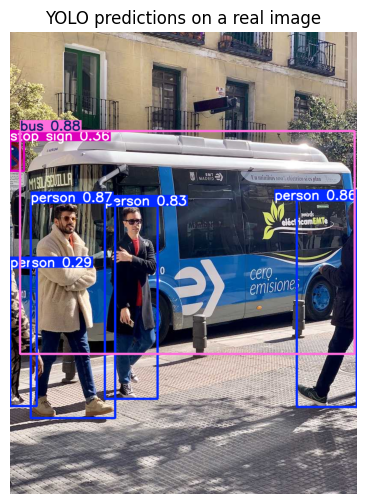

In [9]:
%matplotlib inline
if not ULTRALYTICS_AVAILABLE:
    print("Пропуск примера инференса: Ultralytics недоступен.")
else:
    from ultralytics.utils import ASSETS

    sample_image = ASSETS / "bus.jpg"
    results = model.predict(sample_image, conf=0.25, verbose=False)
    first = results[0]

    print("Predicted classes:", first.boxes.cls.cpu().numpy()[:10])
    print("Predicted confidences:", np.round(first.boxes.conf.cpu().numpy()[:10], 3))

    if MPL_AVAILABLE:
        plotted = first.plot()
        plt.figure(figsize=(10, 6))
        plt.imshow(plotted[..., ::-1])
        plt.axis("off")
        plt.title("YOLO predictions on a real image")
        plt.show()


## 11. Взгляд с позиции deployment

YOLO особенно полезен в курсе, если хочется связать теорию deep learning с реальным deploy.

Почему?

Потому что типичный workflow охватывает:

- обучение  
- валидацию  
- инференс  
- экспорт в ONNX и другие форматы  
- развёртывание на edge или сервере

Поэтому YOLO педагогически ценен: студент видит не только архитектуру, но и правдоподобный путь от датасета до реально работающего детектора.


## 11.1 Deployment story подробнее

YOLO стал особенно доминирующим в учебной и индустриальной среде потому, что очень хорошо связывается с deployment.

Реалистичный workflow часто выглядит так:

1. подготовить или разметить датасет
2. дообучить pretrained checkpoint
3. провалидировать по mAP и визуальному анализу
4. запустить batch или streaming inference
5. экспортировать в удобный runtime-формат
6. развернуть на GPU, сервере, edge-устройстве или embedded-платформе

Педагогически это важно потому, что студент видит не только фазу “обучение в ноутбуке”, но и весь жизненный цикл модели.


## Упражнения

1. Обучайте на `coco8.yaml` дольше и сравните предсказания.  
2. Замените `yolov8n.pt` на более крупный checkpoint и сравните скорость и качество.  
3. Меняйте confidence threshold и качественно анализируйте precision-recall tradeoff.  
4. Экспортируйте модель и опишите путь к развёртыванию.


## Источники

- Материал расширен на основе материалов курса и [deepmachinelearning.ru](https://deepmachinelearning.ru/docs/Neural-networks/Object-detection).  
- Исходная статья YOLO: *You Only Look Once: Unified, Real-Time Object Detection*.  
- Документация Ultralytics по современному обучению и deployment.


In [ ]:
# Заготовка упражнения: сравните confidence thresholds

if not ULTRALYTICS_AVAILABLE:
    print("Для упражнения по YOLO нужен пакет ultralytics.")
else:
    for conf in [0.15, 0.25, 0.50]:
        results = model.predict(sample_image, conf=conf, verbose=False)
        count = len(results[0].boxes)
        print(f"conf={conf:.2f} -> detections={count}")
